In [ ]:
import numpy as np
import pandas as pd


In [ ]:
a=pd.read_csv('/content/Unified_Leads.csv')
print(a)
print(a.size)
print(a.shape)
print(a.isna().sum())

                   Name  contact_number                    Contact_email  \
0          Anjali Singh      9931980478      anjali.singh878@hotmail.com   
1            Kiran Bose      6474315136        kiran.bose601@example.com   
2      Karthik Malhotra      6753707898  karthik.malhotra329@example.com   
3         Anjali Sharma      9439163624      anjali.sharma85@example.com   
4          Sneha Kapoor      9878269840         sneha.kapoor46@gmail.com   
...                 ...             ...                              ...   
27370       Rohit Reddy      6992973331       rohit.reddy220@hotmail.com   
27371      Kiran Shetty      9410734029      kiran.shetty925@outlook.com   
27372       Neha Shetty      9508547875         neha.shetty6@example.com   
27373      Nikhil Yadav      7870690595      nikhil.yadav620@outlook.com   
27374      Nikhil Reddy      8750283113        nikhil.reddy172@gmail.com   

          creation_date first_call_attempt               lead_status  \
0      03-02-20

In [ ]:
print("LEAD STATUS")
print(a["lead_status"].value_counts(dropna=False))

print("\nLEAD STAGE")
print(a["lead_stage"].value_counts(dropna=False))

print("\nLEAD TAG")
print(a["lead_tag"].value_counts(dropna=False))

LEAD STATUS
lead_status
CLOSED                                   12279
PENDING WITH EXECUTIVE                    7947
NOT CONNECTED - RESCHEDULED BY SYSTEM     3857
RESCHEDULED BY EXECUTIVE                  2962
NOT CONNECTED - CLOSED BY SYSTEM           328
OPEN                                         2
Name: count, dtype: int64

LEAD STAGE
lead_stage
LOST                  11698
Prospect              10119
Follow Up Required     4713
CONVERTED               845
Name: count, dtype: int64

LEAD TAG
lead_tag
NaN                    11416
not-interested         10869
cold                    4024
warm                     446
lost-to-competition      303
hot                      236
call-not-connected        52
already-purchased         29
Name: count, dtype: int64


In [ ]:
a["Converted"] = (a["lead_stage"] == "CONVERTED").astype(int)

In [ ]:
a["Converted"].value_counts()

,count
Converted,
0,26530
1,845


In [ ]:
missing = a.isnull().sum()

print(missing[missing > 0])

first_call_attempt     6729
lead_tag              11416
last_call_date         6729
last_call_time         6729
references            27375
dtype: int64


In [ ]:
a = a.drop(columns=["references"])

In [ ]:
a.isnull().sum()

,0
Name,0
contact_number,0
Contact_email,0
creation_date,0
first_call_attempt,6729
lead_status,0
lead_stage,0
lead_tag,11416
assigned_to,0
last_call_date,6729


In [ ]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27375 entries, 0 to 27374
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Name                27375 non-null  object
 1   contact_number      27375 non-null  int64 
 2   Contact_email       27375 non-null  object
 3   creation_date       27375 non-null  object
 4   first_call_attempt  20646 non-null  object
 5   lead_status         27375 non-null  object
 6   lead_stage          27375 non-null  object
 7   lead_tag            15959 non-null  object
 8   assigned_to         27375 non-null  object
 9   last_call_date      20646 non-null  object
 10  last_call_time      20646 non-null  object
 11  campaign_name       27375 non-null  object
 12  source_type         27375 non-null  object
 13  source_name         27375 non-null  object
 14  Converted           27375 non-null  int64 
dtypes: int64(2), object(13)
memory usage: 3.1+ MB


In [ ]:
a["creation_date"] = pd.to_datetime(a["creation_date"], errors="coerce")
a["first_call_attempt"] = pd.to_datetime(a["first_call_attempt"], errors="coerce")
a["last_call_date"] = pd.to_datetime(a["last_call_date"], errors="coerce")

/tmp/ipykernel_2267/3529277745.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  a["first_call_attempt"] = pd.to_datetime(a["first_call_attempt"], errors="coerce")
/tmp/ipykernel_2267/3529277745.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  a["last_call_date"] = pd.to_datetime(a["last_call_date"], errors="coerce")


In [ ]:
a[["creation_date", "first_call_attempt", "last_call_date"]].dtypes

,0
creation_date,datetime64[ns]
first_call_attempt,datetime64[ns]
last_call_date,datetime64[ns]


In [ ]:
a[["creation_date", "first_call_attempt", "last_call_date"]].head(10)

,creation_date,first_call_attempt,last_call_date
0,2026-03-02 22:31:00,NaT,NaT
1,2026-03-02 21:46:00,NaT,NaT
2,2026-03-02 21:28:00,NaT,NaT
3,2026-03-02 19:59:00,NaT,NaT
4,2026-03-02 19:19:00,NaT,NaT
5,2026-03-02 19:09:00,NaT,NaT
6,2026-03-02 19:00:00,NaT,NaT
7,2026-03-02 18:35:00,NaT,NaT
8,2026-03-02 18:09:00,NaT,NaT
9,2026-03-02 17:23:00,NaT,NaT


In [ ]:
a[["creation_date", "first_call_attempt", "last_call_date"]].describe()

,creation_date,first_call_attempt,last_call_date
count,12778,20646,20646
mean,2025-06-22 22:28:20.533730048,2025-10-05 13:17:13.048532480,2025-10-15 07:14:36.152281600
min,2025-01-07 00:02:00,2025-06-02 13:01:00,2025-06-02 13:01:00
25%,2025-05-08 16:51:15,2025-08-27 15:29:15,2025-09-01 15:04:15
50%,2025-06-08 22:00:00,2025-10-16 10:24:00,2025-10-29 17:24:00
75%,2025-08-12 05:28:00,2025-11-22 18:03:45,2025-12-04 16:00:00
max,2026-08-01 06:26:00,2025-12-30 13:16:00,2025-12-31 10:41:00


In [ ]:
a["Days_To_First_Call"] = (
    a["first_call_attempt"] - a["creation_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [ ]:
a[["creation_date", "first_call_attempt", "Days_To_First_Call"]].head(10)

,creation_date,first_call_attempt,Days_To_First_Call
0,2026-03-02 22:31:00,NaT,NaN
1,2026-03-02 21:46:00,NaT,NaN
2,2026-03-02 21:28:00,NaT,NaN
3,2026-03-02 19:59:00,NaT,NaN
4,2026-03-02 19:19:00,NaT,NaN
5,2026-03-02 19:09:00,NaT,NaN
6,2026-03-02 19:00:00,NaT,NaN
7,2026-03-02 18:35:00,NaT,NaN
8,2026-03-02 18:09:00,NaT,NaN
9,2026-03-02 17:23:00,NaT,NaN


In [ ]:
a[["creation_date", "first_call_attempt", "Days_To_First_Call"]].head(10)

,creation_date,first_call_attempt,Days_To_First_Call
0,2026-03-02 22:31:00,NaT,NaN
1,2026-03-02 21:46:00,NaT,NaN
2,2026-03-02 21:28:00,NaT,NaN
3,2026-03-02 19:59:00,NaT,NaN
4,2026-03-02 19:19:00,NaT,NaN
5,2026-03-02 19:09:00,NaT,NaN
6,2026-03-02 19:00:00,NaT,NaN
7,2026-03-02 18:35:00,NaT,NaN
8,2026-03-02 18:09:00,NaT,NaN
9,2026-03-02 17:23:00,NaT,NaN


In [ ]:
a["Days_Between_Calls"] = (
    a["last_call_date"] - a["first_call_attempt"]
).dt.total_seconds() / (24 * 60 * 60)

In [ ]:
a[["first_call_attempt", "last_call_date", "Days_Between_Calls"]].head(10)

,first_call_attempt,last_call_date,Days_Between_Calls
0,NaT,NaT,NaN
1,NaT,NaT,NaN
2,NaT,NaT,NaN
3,NaT,NaT,NaN
4,NaT,NaT,NaN
5,NaT,NaT,NaN
6,NaT,NaT,NaN
7,NaT,NaT,NaN
8,NaT,NaT,NaN
9,NaT,NaT,NaN


In [ ]:
a["Creation_Year"] = a["creation_date"].dt.year
a["Creation_Month"] = a["creation_date"].dt.month
a["Creation_Day"] = a["creation_date"].dt.day
a["Creation_Weekday"] = a["creation_date"].dt.dayofweek

In [ ]:
a[[
    "creation_date",
    "Creation_Year",
    "Creation_Month",
    "Creation_Day",
    "Creation_Weekday"
]].head(10)

,creation_date,Creation_Year,Creation_Month,Creation_Day,Creation_Weekday
0,2026-03-02 22:31:00,2026.0,3.0,2.0,0.0
1,2026-03-02 21:46:00,2026.0,3.0,2.0,0.0
2,2026-03-02 21:28:00,2026.0,3.0,2.0,0.0
3,2026-03-02 19:59:00,2026.0,3.0,2.0,0.0
4,2026-03-02 19:19:00,2026.0,3.0,2.0,0.0
5,2026-03-02 19:09:00,2026.0,3.0,2.0,0.0
6,2026-03-02 19:00:00,2026.0,3.0,2.0,0.0
7,2026-03-02 18:35:00,2026.0,3.0,2.0,0.0
8,2026-03-02 18:09:00,2026.0,3.0,2.0,0.0
9,2026-03-02 17:23:00,2026.0,3.0,2.0,0.0


In [ ]:
a["Has_First_Call"] = a["first_call_attempt"].notna().astype(int)

In [ ]:
a["Has_First_Call"].value_counts()

,count
Has_First_Call,
1,20646
0,6729


In [ ]:
a["Has_Last_Call"] = a["last_call_date"].notna().astype(int)

In [ ]:
a["Has_Last_Call"].value_counts()

,count
Has_Last_Call,
1,20646
0,6729


In [ ]:
a["lead_tag"] = a["lead_tag"].fillna("No Tag")

In [ ]:
a["lead_tag"].value_counts()

,count
lead_tag,
No Tag,11416
not-interested,10869
cold,4024
warm,446
lost-to-competition,303
hot,236
call-not-connected,52
already-purchased,29


In [ ]:
a.isna().sum()

,0
Name,0
contact_number,0
Contact_email,0
creation_date,14597
first_call_attempt,6729
lead_status,0
lead_stage,0
lead_tag,0
assigned_to,0
last_call_date,6729


In [ ]:
a["creation_date"].head(20)

,creation_date
0,2026-03-02 22:31:00
1,2026-03-02 21:46:00
2,2026-03-02 21:28:00
3,2026-03-02 19:59:00
4,2026-03-02 19:19:00
5,2026-03-02 19:09:00
6,2026-03-02 19:00:00
7,2026-03-02 18:35:00
8,2026-03-02 18:09:00
9,2026-03-02 17:23:00


In [ ]:
a[a["creation_date"].isna()][["creation_date"]].head(20)

,creation_date
32,NaT
33,NaT
34,NaT
35,NaT
36,NaT
37,NaT
38,NaT
39,NaT
40,NaT
41,NaT


In [ ]:
a["creation_date"].isna().sum()

np.int64(14597)

In [ ]:
a.loc[a["creation_date"].isna(), ["creation_date", "first_call_attempt", "lead_status", "lead_stage"]].head(20)

,creation_date,first_call_attempt,lead_status,lead_stage
32,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
33,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
34,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
35,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
36,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
37,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
38,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
39,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
40,NaT,NaT,PENDING WITH EXECUTIVE,Prospect
41,NaT,NaT,PENDING WITH EXECUTIVE,Prospect


In [ ]:
original = pd.read_csv('/content/Unified_Leads.csv')

In [ ]:
original["creation_date"].head(40)

,creation_date
0,03-02-2026 22:31
1,03-02-2026 21:46
2,03-02-2026 21:28
3,03-02-2026 19:59
4,03-02-2026 19:19
5,03-02-2026 19:09
6,03-02-2026 19:00
7,03-02-2026 18:35
8,03-02-2026 18:09
9,03-02-2026 17:23


In [ ]:
a["creation_date"] = pd.to_datetime(
    original["creation_date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

In [ ]:
a["creation_date"].isna().sum()

np.int64(0)

In [ ]:
a["creation_date"].head()

,creation_date
0,2026-02-03 22:31:00
1,2026-02-03 21:46:00
2,2026-02-03 21:28:00
3,2026-02-03 19:59:00
4,2026-02-03 19:19:00


In [ ]:
a["Creation_Year"] = a["creation_date"].dt.year
a["Creation_Month"] = a["creation_date"].dt.month
a["Creation_Day"] = a["creation_date"].dt.day
a["Creation_Weekday"] = a["creation_date"].dt.dayofweek

In [ ]:
a["Days_To_First_Call"] = (
    a["first_call_attempt"] - a["creation_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [ ]:
a[[
    "creation_date",
    "Creation_Year",
    "Creation_Month",
    "Creation_Day",
    "Creation_Weekday",
    "Days_To_First_Call"
]].head(10)

,creation_date,Creation_Year,Creation_Month,Creation_Day,Creation_Weekday,Days_To_First_Call
0,2026-02-03 22:31:00,2026,2,3,1,NaN
1,2026-02-03 21:46:00,2026,2,3,1,NaN
2,2026-02-03 21:28:00,2026,2,3,1,NaN
3,2026-02-03 19:59:00,2026,2,3,1,NaN
4,2026-02-03 19:19:00,2026,2,3,1,NaN
5,2026-02-03 19:09:00,2026,2,3,1,NaN
6,2026-02-03 19:00:00,2026,2,3,1,NaN
7,2026-02-03 18:35:00,2026,2,3,1,NaN
8,2026-02-03 18:09:00,2026,2,3,1,NaN
9,2026-02-03 17:23:00,2026,2,3,1,NaN


In [ ]:
a.isnull().sum()

,0
Name,0
contact_number,0
Contact_email,0
creation_date,0
first_call_attempt,6729
lead_status,0
lead_stage,0
lead_tag,0
assigned_to,0
last_call_date,6729


In [ ]:
a["Days_To_First_Call"] = a["Days_To_First_Call"].fillna(0)
a["Days_Between_Calls"] = a["Days_Between_Calls"].fillna(0)

In [ ]:
a[["Days_To_First_Call", "Days_Between_Calls"]].isnull().sum()

,0
Days_To_First_Call,0
Days_Between_Calls,0


In [ ]:
a["last_call_time"] = a["last_call_time"].fillna("No Call")

In [ ]:
a["last_call_time"].isnull().sum()

np.int64(0)

In [ ]:
a.isnull().sum()

,0
Name,0
contact_number,0
Contact_email,0
creation_date,0
first_call_attempt,6729
lead_status,0
lead_stage,0
lead_tag,0
assigned_to,0
last_call_date,6729


In [ ]:
a = a.drop(columns=[
    "Name",
    "contact_number",
    "Contact_email",
    "lead_stage"
])

In [ ]:
a.columns

Index(['creation_date', 'first_call_attempt', 'lead_status', 'lead_tag',
       'assigned_to', 'last_call_date', 'last_call_time', 'campaign_name',
       'source_type', 'source_name', 'Converted', 'Days_To_First_Call',
       'Days_Between_Calls', 'Creation_Year', 'Creation_Month', 'Creation_Day',
       'Creation_Weekday', 'Has_First_Call', 'Has_Last_Call'],
      dtype='object')

In [ ]:
for col in ["lead_status", "lead_tag", "assigned_to", "campaign_name", "source_type", "source_name"]:
    print("\n", col)
    print(a[col].nunique())


 lead_status
6

 lead_tag
8

 assigned_to
26

 campaign_name
26

 source_type
6

 source_name
35


In [ ]:
for col in ["lead_status", "lead_tag", "assigned_to", "campaign_name", "source_type", "source_name"]:
    print("\n", col)
    print(a[col].value_counts())



 lead_status
lead_status
CLOSED                                   12279
PENDING WITH EXECUTIVE                    7947
NOT CONNECTED - RESCHEDULED BY SYSTEM     3857
RESCHEDULED BY EXECUTIVE                  2962
NOT CONNECTED - CLOSED BY SYSTEM           328
OPEN                                         2
Name: count, dtype: int64

 lead_tag
lead_tag
No Tag                 11416
not-interested         10869
cold                    4024
warm                     446
lost-to-competition      303
hot                      236
call-not-connected        52
already-purchased         29
Name: count, dtype: int64

 assigned_to
assigned_to
Anshad               9941
Anandhakrishnan      1784
Megha S              1752
Dharshana            1546
Revathy Reghu        1450
Thaslim New          1407
Riswana              1105
Akhil M A            1029
Munfira               731
Amghitha              710
Devi Nandhana         649
VIJI                  634
Sherin Shaji          574
Ardra Shibu           56

In [ ]:
for col in ["lead_status", "lead_tag", "assigned_to", "campaign_name", "source_type"]:
    print("\n================", col, "================")
    print(
        a.groupby(col)["Converted"]
        .agg(["count", "sum", "mean"])
        .sort_values("mean", ascending=False)
    )


================ lead_status ================
                                       count  sum      mean
lead_status                                                
CLOSED                                 12279  845  0.068817
NOT CONNECTED - CLOSED BY SYSTEM         328    0  0.000000
NOT CONNECTED - RESCHEDULED BY SYSTEM   3857    0  0.000000
OPEN                                       2    0  0.000000
PENDING WITH EXECUTIVE                  7947    0  0.000000
RESCHEDULED BY EXECUTIVE                2962    0  0.000000

================ lead_tag ================
                     count  sum      mean
lead_tag                                 
No Tag               11416  845  0.074019
already-purchased       29    0  0.000000
call-not-connected      52    0  0.000000
cold                  4024    0  0.000000
hot                    236    0  0.000000
lost-to-competition    303    0  0.000000
not-interested       10869    0  0.000000
warm                   446    0  0.000000

========

In [ ]:
a = a.drop(columns=["lead_status", "lead_tag"])

In [ ]:
a.columns

Index(['creation_date', 'first_call_attempt', 'assigned_to', 'last_call_date',
       'last_call_time', 'campaign_name', 'source_type', 'source_name',
       'Converted', 'Days_To_First_Call', 'Days_Between_Calls',
       'Creation_Year', 'Creation_Month', 'Creation_Day', 'Creation_Weekday',
       'Has_First_Call', 'Has_Last_Call'],
      dtype='object')

In [ ]:
X = a.drop(columns=["Converted"])
y = a["Converted"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27375, 16)
y shape: (27375,)


In [ ]:
X = X.drop(columns=[
    "creation_date",
    "first_call_attempt",
    "last_call_date",
    "last_call_time"
])

print(X.columns)
print("Shape:", X.shape)

Index(['assigned_to', 'campaign_name', 'source_type', 'source_name',
       'Days_To_First_Call', 'Days_Between_Calls', 'Creation_Year',
       'Creation_Month', 'Creation_Day', 'Creation_Weekday', 'Has_First_Call',
       'Has_Last_Call'],
      dtype='object')
Shape: (27375, 12)


In [ ]:
X[
    [
        "Days_To_First_Call",
        "Days_Between_Calls",
        "Creation_Year",
        "Creation_Month",
        "Creation_Day",
        "Creation_Weekday",
        "Has_First_Call",
        "Has_Last_Call"
    ]
].describe()

,Days_To_First_Call,Days_Between_Calls,Creation_Year,Creation_Month,Creation_Day,Creation_Weekday,Has_First_Call,Has_Last_Call
count,27375.000000,27375.000000,27375.000000,27375.000000,27375.000000,27375.00000,27375.000000,27375.000000
mean,4.620658,7.352000,2025.007196,9.174320,14.632548,2.68705,0.754192,0.754192
std,14.083015,21.997736,0.084527,1.941857,8.782951,1.77618,0.430573,0.430573
min,0.000000,0.000000,2025.000000,1.000000,1.000000,0.00000,0.000000,0.000000
25%,0.020486,0.000000,2025.000000,8.000000,6.000000,1.00000,1.000000,1.000000
50%,0.757639,0.000000,2025.000000,9.000000,14.000000,2.00000,1.000000,1.000000
75%,2.617708,0.000000,2025.000000,11.000000,23.000000,4.00000,1.000000,1.000000
max,157.733333,197.068056,2026.000000,12.000000,31.000000,6.00000,1.000000,1.000000


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "assigned_to",
    "campaign_name",
    "source_type",
    "source_name"
]

numerical_cols = [
    "Days_To_First_Call",
    "Days_Between_Calls",
    "Creation_Year",
    "Creation_Month",
    "Creation_Day",
    "Creation_Weekday",
    "Has_First_Call",
    "Has_Last_Call"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining conversion rate:", y_train.mean())
print("Testing conversion rate :", y_test.mean())

X_train: (21900, 12)
X_test : (5475, 12)
y_train: (21900,)
y_test : (5475,)

Training conversion rate: 0.0308675799086758
Testing conversion rate : 0.0308675799086758


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (21900, 100)
X_test_processed shape : (5475, 100)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler

log_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

X_train_log = log_preprocessor.fit_transform(X_train)
X_test_log = log_preprocessor.transform(X_test)

print("X_train_log shape:", X_train_log.shape)
print("X_test_log shape:", X_test_log.shape)

X_train_log shape: (21900, 100)
X_test_log shape: (5475, 100)


In [ ]:
log_model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_log, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = log_model.predict(X_test_log)
y_prob = log_model.predict_proba(X_test_log)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy : 0.8365296803652968
Precision: 0.1273100616016427
Recall   : 0.7337278106508875
F1 Score : 0.2169728783902012
ROC-AUC  : 0.8636711370626532

Confusion Matrix:
[[4456  850]
 [  45  124]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      5306
           1       0.13      0.73      0.22       169

    accuracy                           0.84      5475
   macro avg       0.56      0.79      0.56      5475
weighted avg       0.96      0.84      0.89      5475



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train_processed, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [ ]:
y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.8721461187214612
Precision: 0.15203145478374835
Recall   : 0.6863905325443787
F1 Score : 0.24892703862660945
ROC-AUC  : 0.8211581396075003

Confusion Matrix:
[[4659  647]
 [  53  116]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      5306
           1       0.15      0.69      0.25       169

    accuracy                           0.87      5475
   macro avg       0.57      0.78      0.59      5475
weighted avg       0.96      0.87      0.91      5475



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    max_depth=10
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9587214611872146
Precision: 0.39636363636363636
Recall   : 0.6449704142011834
F1 Score : 0.49099099099099097
ROC-AUC  : 0.9056315614566071

Confusion Matrix:
[[5140  166]
 [  60  109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5306
           1       0.40      0.64      0.49       169

    accuracy                           0.96      5475
   macro avg       0.69      0.81      0.73      5475
weighted avg       0.97      0.96      0.96      5475



In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost trained successfully")

XGBoost trained successfully


In [ ]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.9795433789954338
Precision: 0.8701298701298701
Recall   : 0.39644970414201186
F1 Score : 0.5447154471544715
ROC-AUC  : 0.9210082590435746

Confusion Matrix:
[[5296   10]
 [ 102   67]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5306
           1       0.87      0.40      0.54       169

    accuracy                           0.98      5475
   macro avg       0.93      0.70      0.77      5475
weighted avg       0.98      0.98      0.98      5475



| Model               |   Accuracy |  Precision |     Recall |         F1 |    ROC-AUC |
| ------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression |     83.65% |     12.73% | **73.37%** |     21.70% |     86.37% |
| Decision Tree       |     87.21% |     15.20% |     68.64% |     24.89% |     82.12% |
| Random Forest       |     95.87% |     39.64% |     64.50% |     49.10% |     90.56% |
| **XGBoost**         | **97.95%** | **87.01%** |     39.64% | **54.47%** | **92.10%** |


In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(20))

                                       Feature  Importance
28      cat__campaign_name_Business Accounting    0.277299
98                         num__Has_First_Call    0.211048
4                     cat__assigned_to_Anshad     0.077381
72                  cat__source_name_MOVE_LEAD    0.057294
7                   cat__assigned_to_Arunkumar    0.041862
38          cat__campaign_name_Python Knovista    0.033069
95                         num__Creation_Month    0.025187
94                          num__Creation_Year    0.020437
13                    cat__assigned_to_Megha S    0.014061
16                    cat__assigned_to_Riswana    0.013492
15              cat__assigned_to_Revathy Reghu    0.011865
80             cat__source_name_full leads.csv    0.010884
1                   cat__assigned_to_Akhil M A    0.009617
68                  cat__source_name_INSTAGRAM    0.009438
99                          num__Has_Last_Call    0.008634
31  cat__campaign_name_Data Analytics Knovista    0.0080

1. Top factors influencing conversion

Based on your XGBoost model:
| Rank | Feature                       | Importance |
| ---- | ----------------------------- | ---------: |
| 1    | Campaign: Business Accounting |     27.73% |
| 2    | Has First Call                |     21.10% |
| 3    | Assigned To: Anshad           |      7.74% |
| 4    | Source: MOVE_LEAD             |      5.73% |
| 5    | Assigned To: Arunkumar        |      4.19% |
| 6    | Campaign: Python Knovista     |      3.31% |
| 7    | Creation Month                |      2.52% |
| 8    | Creation Year                 |      2.04% |


In [ ]:
result = predict_lead(
    assigned_to="Anshad",
    campaign_name="Business Accounting",
    source_type="Website",
    source_name="INSTAGRAM",
    days_to_first_call=1,
    days_between_calls=2,
    creation_year=2026,
    creation_month=9,
    creation_day=10,
    creation_weekday=3,
    has_first_call=1,
    has_last_call=1
)

print("Conversion Probability:", result[0])
print("Prediction:", result[1])

NameError: name 'predict_lead' is not defined

In [ ]:
def predict_lead(
    assigned_to,
    campaign_name,
    source_type,
    source_name,
    days_to_first_call,
    days_between_calls,
    creation_year,
    creation_month,
    creation_day,
    creation_weekday,
    has_first_call,
    has_last_call,
):
    input_data = pd.DataFrame(
        [
            {
                "assigned_to": assigned_to,
                "campaign_name": campaign_name,
                "source_type": source_type,
                "source_name": source_name,
                "Days_To_First_Call": days_to_first_call,
                "Days_Between_Calls": days_between_calls,
                "Creation_Year": creation_year,
                "Creation_Month": creation_month,
                "Creation_Day": creation_day,
                "Creation_Weekday": creation_weekday,
                "Has_First_Call": has_first_call,
                "Has_Last_Call": has_last_call,
            }
        ]
    )

    processed_input = preprocessor.transform(input_data)

    # Predict probability and class
    probability = xgb_model.predict_proba(processed_input)[:, 1][0]
    prediction = xgb_model.predict(processed_input)[0]

    return probability, prediction


result = predict_lead(
    assigned_to="Anshad",
    campaign_name="Business Accounting",
    source_type="Website",
    source_name="INSTAGRAM",
    days_to_first_call=1,
    days_between_calls=2,
    creation_year=2026,
    creation_month=9,
    creation_day=10,
    creation_weekday=3,
    has_first_call=1,
    has_last_call=1,
)

print("Conversion Probability:", result[0])
print("Prediction:", result[1])

Conversion Probability: 0.14939672
Prediction: 0


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

thresholds = np.arange(0.10, 0.51, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.10 | Precision: 0.430 | Recall: 0.639 | F1: 0.514
Threshold: 0.15 | Precision: 0.508 | Recall: 0.586 | F1: 0.544
Threshold: 0.20 | Precision: 0.578 | Recall: 0.550 | F1: 0.564
Threshold: 0.25 | Precision: 0.636 | Recall: 0.527 | F1: 0.576
Threshold: 0.30 | Precision: 0.706 | Recall: 0.497 | F1: 0.583
Threshold: 0.35 | Precision: 0.734 | Recall: 0.473 | F1: 0.576
Threshold: 0.40 | Precision: 0.782 | Recall: 0.467 | F1: 0.585
Threshold: 0.45 | Precision: 0.837 | Recall: 0.426 | F1: 0.565
Threshold: 0.50 | Precision: 0.870 | Recall: 0.396 | F1: 0.545


| Metric    |    Result |
| --------- | --------: |
| Precision | **78.2%** |
| Recall    | **46.7%** |
| F1-score  | **58.5%** |
| ROC-AUC   | **92.1%** |


In [ ]:
def predict_lead(assigned_to,
                 campaign_name,
                 source_type,
                 source_name,
                 days_to_first_call,
                 days_between_calls,
                 creation_year,
                 creation_month,
                 creation_day,
                 creation_weekday,
                 has_first_call,
                 has_last_call):

    new_lead = pd.DataFrame([{
        "assigned_to": assigned_to,
        "campaign_name": campaign_name,
        "source_type": source_type,
        "source_name": source_name,
        "Days_To_First_Call": days_to_first_call,
        "Days_Between_Calls": days_between_calls,
        "Creation_Year": creation_year,
        "Creation_Month": creation_month,
        "Creation_Day": creation_day,
        "Creation_Weekday": creation_weekday,
        "Has_First_Call": has_first_call,
        "Has_Last_Call": has_last_call
    }])

    # Preprocess the new lead
    new_lead_processed = preprocessor.transform(new_lead)

    # Get conversion probability
    probability = xgb_model.predict_proba(new_lead_processed)[0][1]

    # Selected threshold
    threshold = 0.40

    # Binary prediction
    prediction = 1 if probability >= threshold else 0

    # Lead priority
    if probability >= 0.40:
        priority = "High Potential"
    elif probability >= 0.20:
        priority = "Medium Potential"
    else:
        priority = "Low Potential"

    return probability, prediction, priority

In [ ]:
result = predict_lead(
    assigned_to="Anshad",
    campaign_name="Business Accounting",
    source_type="Website",
    source_name="INSTAGRAM",
    days_to_first_call=1,
    days_between_calls=2,
    creation_year=2026,
    creation_month=9,
    creation_day=10,
    creation_weekday=3,
    has_first_call=1,
    has_last_call=1
)

print("Conversion Probability:", f"{result[0] * 100:.2f}%")
print("Prediction:", result[1])
print("Lead Priority:", result[2])

Conversion Probability: 14.94%
Prediction: 0
Lead Priority: Low Potential


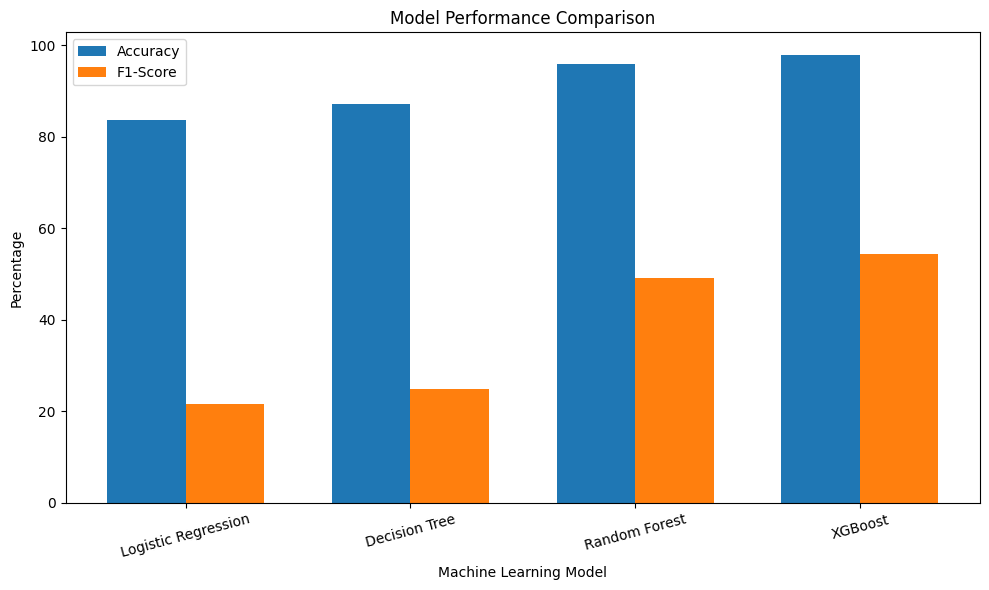

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

accuracy = [83.65, 87.21, 95.87, 97.95]
f1_score = [21.70, 24.89, 49.10, 54.47]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_score, width, label="F1-Score")

plt.xlabel("Machine Learning Model")
plt.ylabel("Percentage")
plt.title("Model Performance Comparison")

plt.xticks(x, models, rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

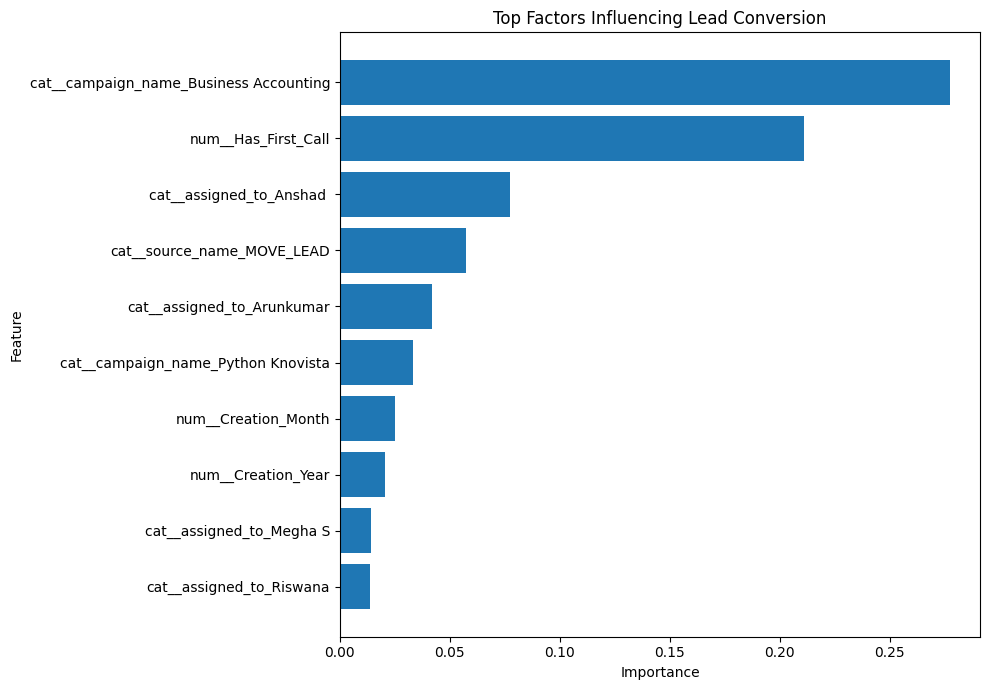

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Lead Conversion")

plt.tight_layout()
plt.show()

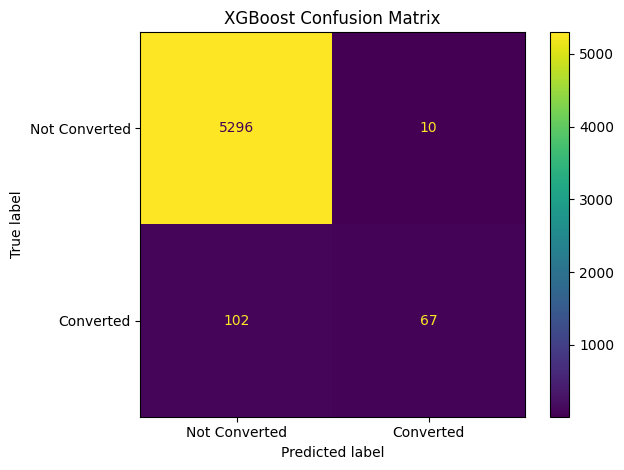

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([[5296, 10],
               [102, 67]])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Converted", "Converted"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

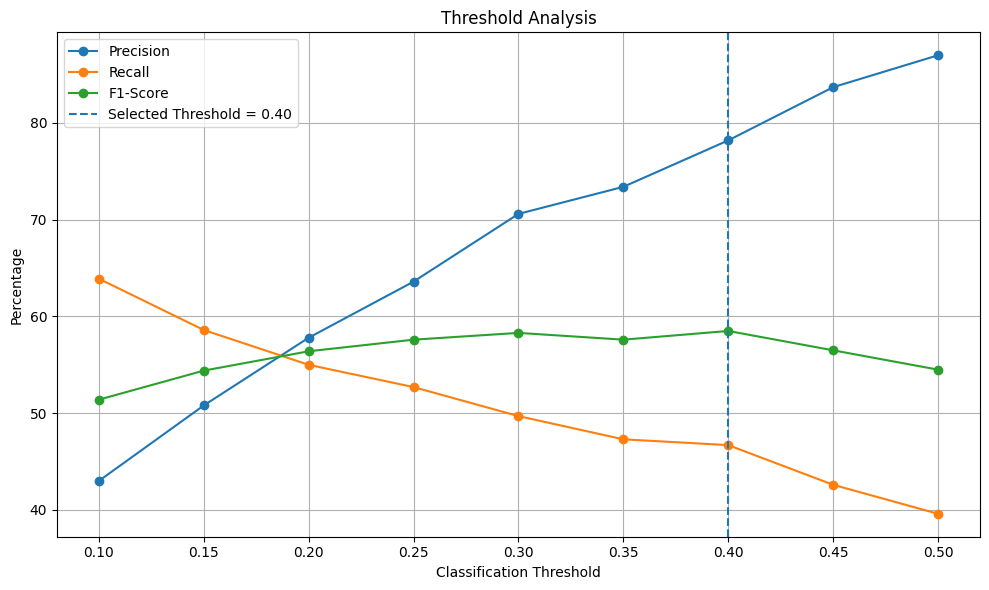

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.array([
    0.10, 0.15, 0.20, 0.25, 0.30,
    0.35, 0.40, 0.45, 0.50
])

precision = np.array([
    0.430, 0.508, 0.578, 0.636, 0.706,
    0.734, 0.782, 0.837, 0.870
])

recall = np.array([
    0.639, 0.586, 0.550, 0.527, 0.497,
    0.473, 0.467, 0.426, 0.396
])

f1 = np.array([
    0.514, 0.544, 0.564, 0.576, 0.583,
    0.576, 0.585, 0.565, 0.545
])

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision * 100, marker="o", label="Precision")
plt.plot(thresholds, recall * 100, marker="o", label="Recall")
plt.plot(thresholds, f1 * 100, marker="o", label="F1-Score")

plt.axvline(
    x=0.40,
    linestyle="--",
    label="Selected Threshold = 0.40"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Percentage")
plt.title("Threshold Analysis")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

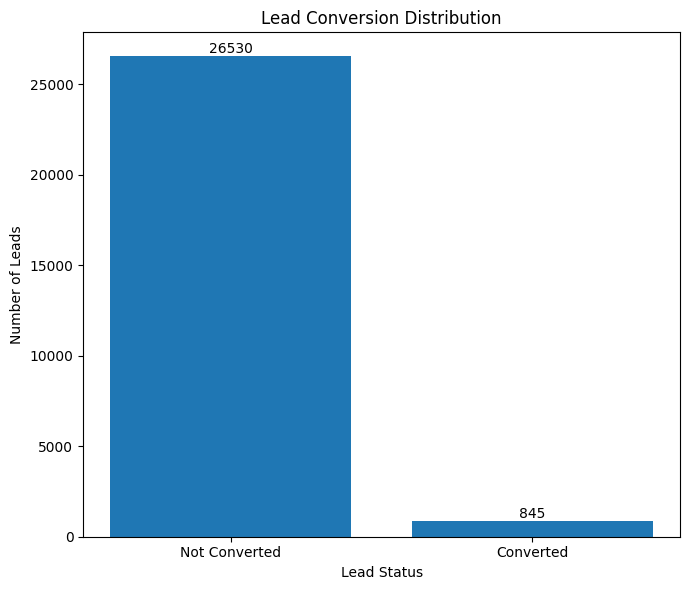

In [ ]:
import matplotlib.pyplot as plt

labels = ["Not Converted", "Converted"]
values = [26530, 845]

plt.figure(figsize=(7, 6))

plt.bar(labels, values)

plt.xlabel("Lead Status")
plt.ylabel("Number of Leads")
plt.title("Lead Conversion Distribution")

for i, value in enumerate(values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

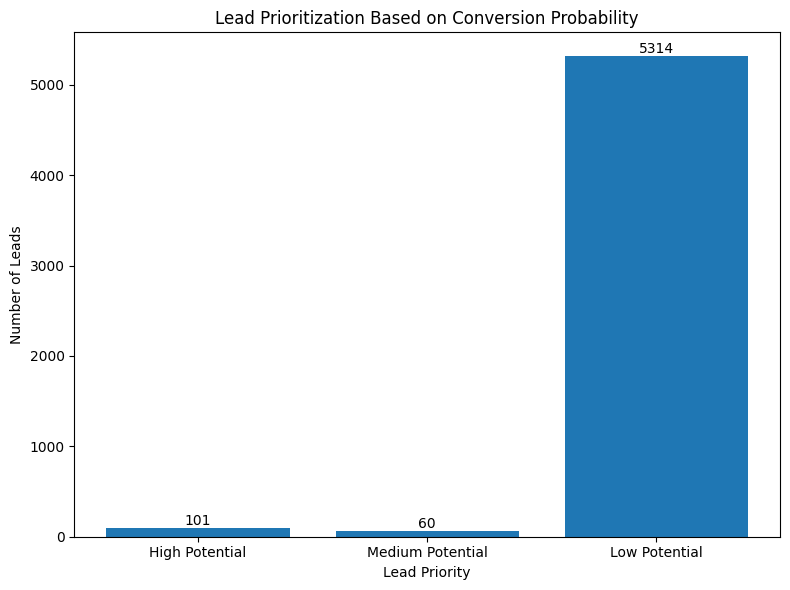

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get conversion probabilities for test leads
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

# Classify leads based on selected probability ranges
priority = np.where(
    y_prob >= 0.40,
    "High Potential",
    np.where(
        y_prob >= 0.20,
        "Medium Potential",
        "Low Potential"
    )
)

priority_counts = pd.Series(priority).value_counts()

# Keep order consistent
order = ["High Potential", "Medium Potential", "Low Potential"]
priority_counts = priority_counts.reindex(order, fill_value=0)

plt.figure(figsize=(8, 6))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.xlabel("Lead Priority")
plt.ylabel("Number of Leads")
plt.title("Lead Prioritization Based on Conversion Probability")

for i, value in enumerate(priority_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Conclusion

The Lead Conversion Prediction project successfully developed a machine learning-based model to predict the likelihood of a lead converting into a customer. The dataset was systematically cleaned, preprocessed, and transformed into relevant features to support effective model training.

Several machine learning algorithms, including Logistic Regression, Decision Tree, Random Forest, and XGBoost, were evaluated and compared. Among these models, XGBoost demonstrated the best overall performance.

The project also identified key factors influencing lead conversion and implemented a lead prioritization system based on predicted conversion probability. This approach can help businesses identify high-potential leads, optimize follow-up activities, and support more effective sales decision-making.

Overall, the project demonstrates the practical application of machine learning and data analysis techniques in lead conversion prediction and provides a useful approach for improving the efficiency of lead management.
